In [28]:
# ------------------------------------------------------------
# Cutthroat: A Topology Optimization Framework
# Author: John A. Gardiner
# ------------------------------------------------------------

# This code is part of the Cutthroat topology optimization framework, which is designed to optimize material distribution in heat exchangers for improved performance. The framework includes mesh generation, finite element analysis, and optimization algorithms. The following code snippet focuses on the simulation of meshes and the integration of a neural network for predicting optimal material distributions.

In [29]:
# -------------------------------------------------------------
# Libraries and Imports
# -------------------------------------------------------------

# Paths and File Handling
import os
import abc
import subprocess
from pathlib import Path
from jinja2 import Template
from typing import Optional
import json
import uuid
from dataclasses import dataclass, field, asdict
from typing import Optional
import gmsh

# Numerical and Visualization Libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import h5py

# Neural Network and Machine Learning Libraries
import torch
import torch.nn as nn
from scipy.ndimage import label
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
from concurrent.futures import ThreadPoolExecutor

In [30]:
# -------------------------------------------------------------
# Torch Device Configuration
# -------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU:", torch.backends.mps.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA RTX A4500


In [31]:
# -------------------------------------------------------------
# Supporting Geometry Generation Classes and Data Structures
# -------------------------------------------------------------

@dataclass
class GeometryConfig:
    """
    Serializable snapshot of a heat exchanger geometry.
    
    Produced by the Generator and consumed by both the MeshGenerator (to build the .msh file)
    and the Optimizer (to map simulation results back onto the original grid).
    
    Fields:
    -------
    grid_nx, grid_ny: int
        Number of grid points in the x and y directions for the reference grid.
    domain_length, domain_height: float
        Physical dimensions of the rectangular fluid domain.
    occupancy_grid : list[list[float]]
        2D list representing the occupancy of the domain, where 0 indicates solid and 1 indicates fluid.Soft (0-1) CNN output before thresholding. Shape: (grid_ny, grid_nx).
        Stored so the CNN state can be reproduced exactly for the same geometry, and so the optimizer can use the same grid for mapping results back to the original geometry.
    obstacle_polygons : list[list[tuple[float, float]]]
        List of polygons representing the obstructions in the geometry. Each polygon is a list of (x, y) coordinates of its vertices.
    config_id : str
        UUID assigned at creation - ties a GeometryConfig to its .msh file and simulation results for reproducibility and traceability.
    """

    grid_nx: int
    grid_ny: int
    domain_length: float
    domain_height: float
    threshold: float
    occupancy_grid: list # shape (grid_ny, grid_nx), values between 0 and 1
    obstacle_polygons: list # list of polygons, where each polygon is a list of (x, y) vertex coordinates
    config_id: str = field(default_factory=lambda: str(uuid.uuid4()))

    # Serialization
    def save(self, path: str | Path) -> None:
        """Save to a JSON file. Mesh files use the same config_id stem."""
        filename = path/f"{self.config_id}.json"
        with open(filename, "w") as f:
            json.dump(asdict(self), f, indent=2)
    
    @classmethod
    def load(cls, path: str | Path) -> "GeometryConfig":
        with open(path) as f:
            data = json.load(f)
        return cls(**data)
    
    @property
    def mesh_filename(self) -> str:
        """Canonical filename derived from config_id."""
        return f"hx_{self.config_id}.msh"
    
    def grid_cell_size(self) -> tuple[float, float]:
        """Physical size of each grid cell (dx, dy)."""
        return (self.domain_length / self.grid_nx, self.domain_height / self.grid_ny)
    
    def cell_center(self, ix: int, iy: int) -> tuple[float, float]:
        """
        Physical (x, y) coordinates of the center of grid cell (ix, iy).
        ix in [0, grid_nx), iy in [0, grid_ny).
        Origin is at the bottome left of the domain
        """
        dx, dy = self.grid_cell_size()
        x = (ix + 0.5) * dx
        y = (iy + 0.5) * dy - self.domain_height / 2
        return (x, y)
    
class HeatExchanger:
    """
    Contains the geometry, mesh, and simulation results for a single heat exchanger design. This is the main data structure that the Generator produces and the Optimizer consumes.

    Parameters:
    id: str
        Unique identifier for this heat exchanger design, typically derived from the GeometryConfig's config_id.
    config_filename: Optional[str]
        Path to the GeometryConfig JSON file that describes the geometry of this heat exchanger. This file is used to generate the mesh and to map simulation results back to the original grid.
    mesh_filename: Optional[str]
        Path to the GMSH .msh file that contains the mesh for this heat exchanger design. This file is generated from the GeometryConfig and is used as input for the simulation.
    result_filename: Optional[str]
        Path to the simulation results file (e.g., Exodus .e file) for this heat exchanger design. This file is generated by running the simulation on the mesh and contains the results that will be analyzed and used for optimization.
    geometry_config: Optional[GeometryConfig]
        An instance of GeometryConfig that describes the geometry of this heat exchanger. This is typically loaded from the config_filename and is used for reference throughout the optimization process.
    obstruction_polygons: Optional[list]
        A list of polygons representing the obstructions in the geometry, extracted from the occupancy grid. Each polygon is a list of (x, y) coordinates of its vertices. This is derived from the GeometryConfig and is used for mesh generation and visualization.
    solved: bool
        A flag indicating whether the simulation for this heat exchanger design has been run and results are available. This is used to track the state of the optimization process.
    results: Optional[dict]
        A dictionary containing the analyzed results from the simulation, such as temperature distribution, flow patterns, and performance metrics. This is derived from the result_filename and is used for optimization and decision-making.
    """
    
    def __init__(
        self,
        id: str,
        mesh_params: dict,
        geometry_config: Optional[GeometryConfig] = None,
    ):
        self.id = id
        self.mesh_params = mesh_params
        self.config_filename = None
        self.mesh_filename = None
        self.result_filename = None
        self.set_filenames()
        
        # Load geometry config and extract obstruction polygons
        self.geometry_config = geometry_config
        self.obstruction_polygons = None
        if geometry_config is None:
            self.load_geometry_config()
        else:
            self.obstruction_polygons = self.geometry_config.obstacle_polygons

        # Check for existing mesh and results
        self.mesh_exists = self.check_for_mesh()
        
        # Simulation state
        self.results = None
        self.solved = self.check_for_existing_results()
    
    def set_filenames(self):
        """Set the mesh_filename and result_filename based on the heat exchanger ID."""
        self.config_filename = f"configs/hx_{self.id}.json"
        self.mesh_filename = f"meshes/hx_{self.id}.msh"
        self.result_filename = f"results/hx_{self.id}.e"

    def load_geometry_config(self):
        """Load the GeometryConfig from the config_filename."""
        self.geometry_config = GeometryConfig.load(self.config_filename)
        self.obstruction_polygons = self.geometry_config.obstacle_polygons

    def check_for_mesh(self) -> bool:
        """Check if the mesh file already exists for this heat exchanger design."""
        if os.path.exists(self.mesh_filename):
            return True
        else:
            self.generate_mesh()
        return os.path.exists(self.mesh_filename)

    def check_for_existing_results(self) -> bool:
        """Check if the result file already exists for this heat exchanger design."""
        if os.path.exists(self.result_filename):
            self.read_results()
        return os.path.exists(self.result_filename)
    
    def read_results(self):
        """Read the simulation results from the result_filename and store them in self.results."""
        # Placeholder for reading results - this would depend on the format of the results file
        self.results = None

    def create_custom_obstruction(self, points: list[tuple[float, float]]) -> int:
        """
        Create a planar surface in GMSH from an ordered list of (x, y) points.
        Returns the GMSH surface tag.
        """
        n_points = len(points)
        gmsh_points = []
        for coord in points:
            pt = gmsh.model.occ.addPoint(coord[0], coord[1], 0)
            gmsh_points.append(pt)
 
        lines = []
        for i in range(n_points):
            line = gmsh.model.occ.addLine(
                gmsh_points[i],
                gmsh_points[(i + 1) % n_points],
            )
            lines.append(line)
 
        cl = gmsh.model.occ.addCurveLoop(lines)
        surface = gmsh.model.occ.addPlaneSurface([cl])
        return surface

    def generate_mesh(self) -> str:
        """
        Returns the path to the written .msh file.
        """
        gmsh.initialize()
        gmsh.model.add(f"hx_{self.id}")
 
        rect = gmsh.model.occ.addRectangle(
            0, 0, 0,
            self.geometry_config.domain_length, self.geometry_config.domain_height,
        )
        gmsh.model.occ.synchronize()
 
        obstructions = []
        for polygon in self.obstruction_polygons:
            surface = self.create_custom_obstruction(polygon)
            obstructions.append(surface)
        gmsh.model.occ.synchronize()
 
        if obstructions:
            cut = gmsh.model.occ.cut(
                [(2, rect)],
                [(2, s) for s in obstructions],
                removeObject=True,
                removeTool=True,
            )
            gmsh.model.occ.synchronize()
            out_dim_tags, _ = cut
            fluid_surfaces = [tag for dim, tag in out_dim_tags if dim == 2]
        else:
            # No obstacles — entire rectangle is the fluid domain
            fluid_surfaces = [rect]
 
        if not fluid_surfaces:
            gmsh.finalize()
            raise RuntimeError(
                "Boolean cut produced no fluid domain. "
                "Check that obstacles don't fill the entire domain."
            )
 
        gmsh.model.addPhysicalGroup(2, fluid_surfaces, name="Fluid")

        # Boundary classification
        gmsh.model.occ.synchronize()
        boundaries = gmsh.model.getBoundary(
            [(2, s) for s in fluid_surfaces], oriented=False
        )
 
        wall_curves, inlet, outlet, top, bottom = [], [], [], [], []
        for dim, tag in boundaries:
            x, y, _ = gmsh.model.occ.getCenterOfMass(dim, tag)
            if abs(x) < 1e-6:
                inlet.append(tag)
            elif abs(x - self.geometry_config.domain_length) < 1e-6:
                outlet.append(tag)
            elif abs(y - self.geometry_config.domain_height / 2) < 1e-6:
                top.append(tag)
            elif abs(y + self.geometry_config.domain_height / 2) < 1e-6:
                bottom.append(tag)
            else:
                wall_curves.append(tag)
 
        if wall_curves:
            gmsh.model.addPhysicalGroup(1, wall_curves, name="Wall")
        if inlet:
            gmsh.model.addPhysicalGroup(1, inlet, name="Inlet")
        if outlet:
            gmsh.model.addPhysicalGroup(1, outlet, name="Outlet")
        if top:
            gmsh.model.addPhysicalGroup(1, top, name="Top")
        if bottom:
            gmsh.model.addPhysicalGroup(1, bottom, name="Bottom")
 
        p = self.mesh_params
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", p["mesh_min"])
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", p["mesh_max"])
        gmsh.option.setNumber("Mesh.Algorithm",               p["mesh_algorithm"])
        gmsh.option.setNumber("Mesh.RecombineAll",             p["mesh_recombine"])
        gmsh.option.setNumber("Mesh.ElementOrder",             p["mesh_element_order"])
 
        gmsh.model.mesh.generate(2)
        gmsh.write(self.mesh_filename)
        gmsh.finalize()

        return self.mesh_filename
    
class HeatExchangerCNN(nn.Module):
    """
    Maps a latent vector z -> occupancy grid of shape (1, grid_ny, grid_nx).

    The output is passed through sigmoid so values are in (0, 1).
    During training, keep the soft output for RL policy log-probs.
    For geometry generation, threshold at 'threshold' to get binary cells,
    then extract connected blobs as obstacle polygons.

    Architecture: fully-connected projection -> reshape -> series of 
    transposed conv upsampling blocks. The final spatial size is determined by grid_nx and grid_ny
    - the network is built to match these exactly.    
    """

    def __init__(
            self,
            latent_dim: int = 32,
            grid_nx: int = 20,
            grid_ny: int = 10,
            base_channels: int = 64,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.base_channels = base_channels

        # Project z to a small spatial feature map, then upsample.
        # We start at (base_channels, 2, 2) and double the spatial dims each block.
        # Number of upsampling blocks needed:
        self._n_ups_x = int(np.ceil(np.log2(grid_nx))) - 1 # number of doublings needed
        self._n_ups_y = int(np.ceil(np.log2(grid_ny))) - 1
        n_blocks = max(self._n_ups_x, self._n_ups_y)

        # FC projection
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4),
            nn.ReLU(),
            nn.Linear(base_channels * 4, base_channels * 2 * 2),
            nn.ReLU()
        )
        self.init_channels = base_channels
        self.init_h = 2
        self.init_w = 2

        # Upsampling blocks
        blocks = []
        in_ch = base_channels
        for i in range(n_blocks):
            out_ch = max(in_ch // 2, 8)
            blocks.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ))
            in_ch = out_ch
        self.ups = nn.ModuleList(blocks)

        # Final 1x1 conv to singe-channel occupancy grid
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Parameters:
        z: Tensor of shape (B, latent_dim)
        
        Returns: 
        Tensor of shape (B, 1, grid_ny, grid_nx) occupancy grid with values in (0, 1)
        """
        B = z.shape[0]
        x = self.fc(z) # (B, base_channels * 2 * 2)
        x = x.view(B, self.init_channels, self.init_h, self.init_w) # (B, base_channels, 2, 2)

        for up in self.ups:
            x = up(x) # upsample
        x = self.head(x) # (B, 1, H, W)
        
        # Crop or interpolate to extract target size
        x = torch.nn.functional.interpolate(
            x, size=(self.grid_ny, self.grid_nx), mode='bilinear', align_corners=False
            )
        x = torch.sigmoid(x) # values in (0, 1)
        return x
    
class GeometryFilter:
    """
    Validates an occupancy grid before committing to mesh generation.

    Checks
    ------
    1. Solid density: fraction of solid cells must be within [min_density, max_density].
    2. Flow path: at least one continuous fluid path from inlet (left) to outlet (right).
    3. No enclosed fluid: every fluid region must connect to both the inlet and outlet boundaries.
       Fluid pockets fully surrounded by solid are rejected.

    Parameters
    ----------
    min_density, max_density : float
        Solid fraction bounds.
    threshold : float
        Binarization threshold, should match HeatExchangerGenerator.
    """

    def __init__(
        self,
        min_density: float = 0.10,
        max_density: float = 0.75,
        threshold: float = 0.5,
    ):
        self.min_density = min_density
        self.max_density = max_density
        self.threshold = threshold

    def is_valid(self, occupancy: np.ndarray) -> tuple[bool, dict]:
        binary = (occupancy >= self.threshold)

        density_ok, density_val = self._check_density(binary)
        flow_ok                 = self._check_flow_path(binary)
        no_pockets              = self._check_no_enclosed_fluid(binary)

        report = {
            "solid_density":      round(float(density_val), 4),
            "density_ok":         density_ok,
            "has_flow_path":      flow_ok,
            "no_enclosed_fluid":  no_pockets,
            "valid":              density_ok and flow_ok and no_pockets,
        }
        return report["valid"], report

    def _check_density(self, binary: np.ndarray) -> tuple[bool, float]:
        density = binary.mean()
        return self.min_density <= density <= self.max_density, density

    def _check_flow_path(self, binary: np.ndarray) -> bool:
        fluid = ~binary
        if not fluid[:, 0].any() or not fluid[:, -1].any():
            return False
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            if region[:, 0].any() and region[:, -1].any():
                return True
        return False

    def _check_no_enclosed_fluid(self, binary: np.ndarray) -> bool:
        """
        Check that no fluid region is fully enclosed by solid.

        A fluid region is considered enclosed if it does not touch the inlet
        and outlet boundaries. Touching both boundaries means the fluid is reachable 
        from outside the heat exchanger, which is the physical requirement.
        """
        fluid = ~binary
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            touches_boundary = (
                region[:, 0].any()   and   # left column (inlet)
                region[:, -1].any()       # right column (outlet)
            )
            if not touches_boundary:
                return False
        return True
    
class FilterLoss(nn.Module):
    """
    Differentiable proxy for all three hard GeometryFilter checks. 
    Additionally, includes extra terms to encourage desirable properties like diversity, tortuosity, fragmentation, fine channel structure, sharp interfaces, and non-periodicity — all of which are common failure modes when training a CNN with only the basic filter checks as supervision.

    Parameters
    ----------
    min_density, max_density : float
        Target solid fraction bounds.
    density_weight : float
        Weight for the density loss term. Since density is a fundamental constraint, this should be set high enough to strongly penalize designs that are too sparse or too dense.
    flow_weight : float
        Weight for the flow path loss term. Since a clear flow path is critical, this should be set high to strongly penalize designs that block the inlet or outlet.
    pocket_weight : float
        Weight for the enclosed fluid loss term. Since enclosed fluid is a hard fail, this should be set high to strongly penalize any pockets.
    diversity_weight : float
        Weight for the diversity loss term, which encourages variation in the generated geometries across a batch of latent vectors.
    diversity_min_std : float
        Minimum standard deviation for the diversity loss term. If the standard deviation of the occupancy grids in a batch falls below this threshold, the diversity loss will increase to encourage more variation.
    tortuosity_weight : float
        Weight for the tortuosity loss term, which encourages more tortuous flow paths to break up straight channels that can cause periodic patterns.
    min_tortuosity : float
        Minimum tortuosity for the tortuosity loss term. If the tortuosity of the flow paths in a generated geometry falls below this threshold, the tortuosity loss will increase to encourage more winding paths.
    fragmentation_weight : float
        Weight for the fragmentation loss term, which discourages large blocks of solid or fluid and encourages more, smaller channels.
    channel_scale_weight : float
        Weight for the channel scale loss term, which encourages finer channel structures by penalizing deviations from a target channel width.
    target_channel_width : float
        Target channel width for the channel scale loss term. This pushes the generator toward producing features of a certain size, which can help avoid overly large solid blocks or wide fluid channels.
    interface_weight : float
        Weight for the interface loss term, which encourages sharper solid-fluid interfaces by penalizing intermediate occupancy values and promoting more binary-like outputs.
    periodicity_weight : float
        Weight for the periodicity loss term, which discourages periodic patterns in the generated geometries by penalizing repeating structures in the occupancy grid.
    """

    def __init__(
        self,
        min_density: float = 0.20,
        max_density: float = 0.80,
        density_weight: float = 3.0,            # increase to more strongly penalize densities outside the valid range
        flow_weight: float = 2.5,               # increase to strongly encourage a clear flow path
        pocket_weight: float = 7.5,             # enclosed fluid is a hard fail, increase to punish it more heavily
        diversity_weight: float = 3.0,          # increase to encourage more diversity in the batches
        diversity_min_std: float = 0.25,
        tortuosity_weight: float = 0.5,         # encourage tortuosity to break up straight channels that can cause periodic patterns
        min_tortuosity: float = 0.05, 
        fragmentation_weight: float = 5.0,      # increase to discourage large blocks of solid or fluid — encourages more, smaller channels
        channel_scale_weight: float = 4.0,      # increase to encourage fine structure
        target_channel_width: float = 0.10,     # pushes toward finer features
        interface_weight: float = 2.0,          # increase to encourage sharper solid-fluid interfaces
        periodicity_weight: float = 2.5,        # increase to discourage periodic patterns 
        sharpness_weight: float = 4.0,          # increase to encourage sharper transitions in the occupancy grid, reducing ambiguous values between solid and fluid
    ):
        super().__init__()
        self.min_density = min_density
        self.max_density = max_density
        self.density_weight = density_weight
        self.flow_weight = flow_weight
        self.pocket_weight = pocket_weight
        self.diversity_weight = diversity_weight
        self.diversity_min_std = diversity_min_std
        self.tortuosity_weight = tortuosity_weight
        self.min_tortuosity = min_tortuosity
        self.fragmentation_weight = fragmentation_weight
        self.channel_scale_weight = channel_scale_weight
        self.target_channel_width = target_channel_width
        self.interface_weight = interface_weight
        self.periodicity_weight = periodicity_weight
        self.sharpness_weight = sharpness_weight

    def forward(self, soft_grid):
        density_loss        = self._density_loss(soft_grid)
        flow_loss           = self._flow_loss(soft_grid)
        pocket_loss         = self._pocket_loss(soft_grid)
        diversity_loss      = self._diversity_loss(soft_grid, self.diversity_min_std)
        tortuosity_loss     = self._tortuosity_loss(soft_grid, self.min_tortuosity)
        fragmentation_loss  = self._fragmentation_loss(soft_grid)
        channel_scale_loss  = self._channel_scale_loss(soft_grid, self.target_channel_width)
        interface_loss      = self._interface_loss(soft_grid)
        periodicity_loss    = self._periodicity_loss(soft_grid)
        sharpness_loss      = self._sharpness_loss(soft_grid)

        total = (
            self.density_weight         * density_loss          +
            self.flow_weight            * flow_loss             +
            self.pocket_weight          * pocket_loss           +
            self.diversity_weight       * diversity_loss        +
            self.tortuosity_weight      * tortuosity_loss       +
            self.fragmentation_weight   * fragmentation_loss    +
            self.channel_scale_weight   * channel_scale_loss    +
            self.interface_weight       * interface_loss        +
            self.periodicity_weight     * periodicity_loss      +
            self.sharpness_weight       * sharpness_loss        
        )

        breakdown = {
            "density_loss":         density_loss.item(),
            "flow_loss":            flow_loss.item(),
            "pocket_loss":          pocket_loss.item(),
            "diversity_loss":       diversity_loss.item(),
            "tortuosity_loss":      tortuosity_loss.item(),
            "fragmentation_loss":   fragmentation_loss.item(),
            "channel_scale_loss":   channel_scale_loss.item(),
            "interface_loss":       interface_loss.item(),
            "periodicity_loss":     periodicity_loss.item(),
            "sharpness_loss":       sharpness_loss.item(),
            "total_loss":           total.item(),
        }

        return total, breakdown

    def _density_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes designs that are too sparse or too dense, based on the average occupancy of the grid.
        """
        density_soft = soft_grid.mean(dim=[1, 2, 3])

        too_low_soft  = torch.relu(self.min_density - density_soft) ** 2
        # Asymmetric: penalize too-high more aggressively than too-low
        # since the current failure mode is density collapsing to 1.0
        too_high_soft = (torch.relu(density_soft - self.max_density) ** 2) * 3.0
        hinge_loss = (too_low_soft + too_high_soft).mean()

        target = (self.min_density + self.max_density) / 2.0
        pull_loss = (
            torch.relu(self.min_density - density_soft)
            * torch.abs(density_soft - target)
        ).mean()

        # Straight-through hard density
        binary = (soft_grid >= 0.5).float()
        binary_ste = soft_grid + (binary - soft_grid).detach()
        density_hard = binary_ste.mean(dim=[1, 2, 3])
        too_low_hard  = torch.relu(self.min_density - density_hard) ** 2
        too_high_hard = (torch.relu(density_hard - self.max_density) ** 2) * 3.0
        hard_loss = (too_low_hard + too_high_hard).mean()

        ambiguous = torch.relu(soft_grid - 0.3) * torch.relu(0.7 - soft_grid)

        # Edge-aware sharpening: ambiguous cells adjacent to decided cells
        # are penalized much more heavily than interior ambiguous cells.
        # A decided cell is one with value < 0.2 (fluid) or > 0.8 (solid).
        decided = ((soft_grid < 0.2) | (soft_grid > 0.8)).float()
        kernel = torch.ones(1, 1, 3, 3, device=soft_grid.device) / 9.0
        near_decided = torch.nn.functional.conv2d(decided, kernel, padding=1)
        # near_decided is high where there are decided neighbors — these are edge cells
        edge_weight = 1.0 + near_decided * 9.0   # up to 10x penalty at edges
        sharpening_loss = (ambiguous * edge_weight).mean() * 4.0

        return hinge_loss + pull_loss + hard_loss + sharpening_loss

    def _flow_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes designs that lack a clear flow path from inlet to outlet.

        Switched to isotropic 3x3 kernel to remove horizontal stripe bias.
        """
        fluid = 1.0 - soft_grid

        inlet_blocking  = (1.0 - fluid[:, :, :, 0]).mean()
        outlet_blocking = (1.0 - fluid[:, :, :, -1]).mean()
        column_loss = inlet_blocking + outlet_blocking

        # Isotropic kernel — no directional bias
        kernel = torch.ones(1, 1, 3, 3, device=soft_grid.device) / 9.0
        neighbor_fluid = torch.nn.functional.conv2d(fluid, kernel, padding=1)
        connectivity_loss = torch.relu(fluid - neighbor_fluid).mean()

        return column_loss + connectivity_loss

    def _pocket_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Differentiable flood-fill pocket detection, matching the updated
        GeometryFilter logic:

        - Reachability is seeded only from left (inlet) and right (outlet) columns.
        Top/bottom boundary contact does not count as reachable, matching the
        filter's requirement that fluid must connect inlet to outlet.
        - Two separate flood fills are run: one from the left, one from the right.
        A fluid cell is only considered valid if reachable from BOTH sides.
        This catches three failure modes:
            1. Enclosed pockets with no boundary contact
            2. Dead-end channels touching only the inlet or only the outlet
            3. Fluid regions touching only top/bottom walls
        """
        fluid = 1.0 - soft_grid
        B, _, H, W = fluid.shape

        # Fluid fraction guard — same as before
        fluid_fraction = fluid.mean(dim=[1, 2, 3])
        min_fluid = 1.0 - self.max_density
        fluid_shortage = torch.relu(min_fluid - fluid_fraction).mean()

        # Downsampling for large grids
        downsample_factor = 1
        if H * W > 50000:
            downsample_factor = 4
            fluid_ds = torch.nn.functional.avg_pool2d(
                fluid, kernel_size=downsample_factor, stride=downsample_factor,
            )
        else:
            fluid_ds = fluid

        _, _, Hd, Wd = fluid_ds.shape
        n_iters = (Hd + Wd) // 4

        def smooth_flood_fill(seed_col: int) -> torch.Tensor:
            """
            Flood fill using avg_pool2d instead of max_pool2d.

            avg_pool2d distributes gradient to all neighbors equally rather
            than only to the winner, giving the CNN a usable learning signal
            throughout the reachability map.

            The avg_pool with a scaling factor >1 approximates max behavior
            (high values dominate the average of their neighborhood) while
            keeping gradients alive. We clamp to [0,1] after each step to
            prevent runaway amplification.
            """
            reachable = torch.zeros_like(fluid_ds)
            reachable[:, :, :, seed_col] = fluid_ds[:, :, :, seed_col]

            # Reduce alpha from 4.0 to 2.0 — less amplification means fewer
            # cells hit the clamp ceiling, preserving more gradient paths.
            # Slower propagation speed is compensated by n_iters being based
            # on grid dimensions already.
            alpha = 2.0

            for _ in range(n_iters):
                expanded = torch.nn.functional.avg_pool2d(
                    reachable * alpha,
                    kernel_size=3,
                    stride=1,
                    padding=1,
                )
                # Use sigmoid instead of clamp — smooth saturation keeps gradients
                # alive near the ceiling rather than zeroing them out
                reachable = torch.sigmoid(expanded * 4.0 - 2.0) * fluid_ds
                reachable[:, :, :, seed_col] = fluid_ds[:, :, :, seed_col]

            return reachable

        reachable_from_left  = smooth_flood_fill(0)
        reachable_from_right = smooth_flood_fill(-1)

        if downsample_factor > 1:
            reachable_from_left = torch.nn.functional.interpolate(
                reachable_from_left,  size=(H, W), mode="bilinear", align_corners=False
            )
            reachable_from_right = torch.nn.functional.interpolate(
                reachable_from_right, size=(H, W), mode="bilinear", align_corners=False
            )

        reachable_both = torch.min(reachable_from_left, reachable_from_right)
        enclosed = fluid * torch.relu(fluid - reachable_both)

        return enclosed.mean() + fluid_shortage
    
    def _diversity_loss(
        self,
        soft_grid: torch.Tensor,
        min_std: float = 0.15,
    ) -> torch.Tensor:
        """
        Penalizes mode collapse by encouraging two kinds of diversity:

        1. Spatial variance within each sample — the occupancy values should
        vary across the grid, not be uniform. A collapsed CNN produces
        nearly identical values everywhere (e.g. all ~0.5), giving near-zero
        spatial std. We penalize when per-sample std drops below min_std.

        2. Inter-sample variance across the batch — different latent vectors
        should produce different grids. If all samples in a batch look the
        same, the mean of the batch looks like any individual sample, so the
        std across samples is near zero. We penalize that too.

        Parameters
        ----------
        soft_grid : Tensor of shape (B, 1, grid_ny, grid_nx)
        min_std : float
            Minimum acceptable std. Values below this are penalized.
            0.15 is a reasonable starting point — pure noise has std ~0.29,
            a fully collapsed output has std ~0.0.
        """
        # 1. Spatial variance: std across spatial dims for each sample
        spatial_std = soft_grid.std(dim=[2, 3])          # (B, 1)
        spatial_loss = torch.relu(min_std - spatial_std).mean()

        # 2. Inter-sample variance: std across batch dim at each spatial location
        if soft_grid.shape[0] > 1:
            batch_std = soft_grid.std(dim=0)             # (1, grid_ny, grid_nx)
            batch_loss = torch.relu(min_std - batch_std).mean()
        else:
            batch_loss = torch.tensor(0.0, device=soft_grid.device)

        return spatial_loss + batch_loss

    def _tortuosity_loss(
        self,
        soft_grid: torch.Tensor,
        min_tortuosity: float = 0.3,
    ) -> torch.Tensor:
        """
        Penalizes designs where fluid flows too directly from inlet to outlet.

        Tortuosity is approximated by measuring vertical variation in the
        fluid distribution across x-slices. A straight horizontal channel
        has the same fluid pattern at every x position (low variation).
        A snaking channel shifts up and down across x positions (high variation).

        Specifically: for each x column, compute the center of mass of the
        fluid cells in y. A path that snakes will have a y center-of-mass
        that varies significantly across x. We penalize when that variation
        is below min_tortuosity.

        Parameters
        ----------
        min_tortuosity : float
            Minimum acceptable std of the fluid y-centroid across x columns.
            Normalized to [0, 1] by grid height. 0.3 means the centroid
            should shift by at least 30% of the domain height across the length.
        """
        fluid = 1.0 - soft_grid  # (B, 1, grid_ny, grid_nx)
        B, _, H, W = fluid.shape

        # y coordinate for each row, normalized to [0, 1]
        y_coords = torch.linspace(0, 1, H, device=soft_grid.device)
        y_coords = y_coords.view(1, 1, H, 1).expand(B, 1, H, W)

        # Fluid-weighted y centroid at each x column: (B, 1, W)
        fluid_sum = fluid.sum(dim=2) + 1e-6          # avoid div by zero
        y_centroid = (fluid * y_coords).sum(dim=2) / fluid_sum  # (B, 1, W)

        # Std of the centroid across x — high for snaking, low for straight
        tortuosity = y_centroid.std(dim=2)           # (B, 1)

        # Penalize when tortuosity is below the minimum
        tortuosity_loss = torch.relu(min_tortuosity - tortuosity).mean()
        return tortuosity_loss
    
    
    def _channel_scale_loss(
        self,
        soft_grid: torch.Tensor,
        target_channel_width: float = 0.05,
    ) -> torch.Tensor:
        # Move to CPU for FFT to avoid MPS buffer resize warning,
        # then move result back to original device for the rest of the loss
        device = soft_grid.device
        solid = soft_grid.squeeze(1).cpu()
        B, H, W = solid.shape

        fft = torch.fft.rfft2(solid)
        power = fft.abs() ** 2

        total_power = power.sum(dim=[1, 2], keepdim=True) + 1e-8
        power_norm = power / total_power

        power_x = power_norm.mean(dim=1)   # (B, W//2+1)
        power_y = power_norm.mean(dim=2)   # (B, H)

        target_freq_x = max(1, int(W * target_channel_width))
        target_freq_y = max(1, int(H * target_channel_width))

        high_freq_x = power_x[:, target_freq_x:].sum(dim=1)
        high_freq_y = power_y[:, target_freq_y:].sum(dim=1)
        aspect_loss = torch.relu(high_freq_x - high_freq_y).mean()

        # Tighter band boundaries so the mid-band isn't trivially satisfied.
        # Previous: low_end=5, high_start=40 for H=100 — mid-band is 35 bins wide.
        # New: symmetric around target frequency so the band reward is meaningful.
        target_bin = max(1, int(H * target_channel_width))
        low_end    = max(1, target_bin // 2)
        high_start = min(H // 2, target_bin * 3)

        low_band_y  = power_y[:, 1:low_end].sum(dim=1)
        mid_band_y  = power_y[:, low_end:high_start].sum(dim=1)
        high_band_y = power_y[:, high_start:].sum(dim=1)

        mid_dominance_loss = (
            torch.relu(low_band_y  - mid_band_y) +
            torch.relu(high_band_y - mid_band_y)
        ).mean()

        # Additional term: penalize DC dominance directly.
        # DC component (index 0) represents the mean value — high DC power means
        # the grid is mostly one value (nearly all solid or all fluid).
        # Excluding DC from ac_power in periodicity_loss isn't enough since
        # channel_scale_loss needs to handle it separately.
        dc_power_y = power_y[:, 0]                    # (B,)
        ac_power_y = power_y[:, 1:].sum(dim=1)        # (B,)
        dc_ratio = dc_power_y / (ac_power_y + 1e-8)
        dc_ratio_clamped = torch.clamp(dc_ratio, 0.0, 20.0)  # prevent extreme values from destabilizing training
        dc_dominance_loss = torch.relu(dc_ratio_clamped - 2.0).mean()  # penalize DC > 2x AC

        return (aspect_loss + mid_dominance_loss + dc_dominance_loss).to(device)
    
    def _fragmentation_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Combined solid and fluid fragmentation loss.

        Replaces the separate _solid_fragmentation_loss and _fluid_fragmentation_loss.
        Both had the same structure but applied to solid and fluid grids respectively,
        so combining them removes the weight imbalance between the two and makes
        tuning simpler — one weight controls the solid/fluid structural balance together.

        Penalizes:
        - Columns where solid blocks the full height (vertical_blockage)
        - Rows where fluid spans the full width (horizontal_openness)
        - Unimodal solid marginal distributions (one large solid blob)
        - Unimodal fluid marginal distributions (one large open space)

        The cross-symmetry between solid and fluid terms means neither phase
        can dominate spatially, which naturally pushes toward interleaved structure.
        """
        solid = soft_grid                   # (B, 1, H, W)
        fluid = 1.0 - soft_grid
        B, _, H, W = solid.shape

        # --- Solid terms ---
        # Penalize columns that are solid all the way through vertically
        col_min_solid = solid.min(dim=2).values           # (B, 1, W)
        vertical_blockage = col_min_solid.mean()

        solid_flat = solid.squeeze(1)                     # (B, H, W)
        solid_y_marginal = solid_flat.mean(dim=2)         # (B, H)
        solid_x_marginal = solid_flat.mean(dim=1)         # (B, W)
        solid_y_var = solid_y_marginal.var(dim=1)         # (B,)
        solid_x_var = solid_x_marginal.var(dim=1)         # (B,)

        min_var = 0.02
        solid_compactness = (
            torch.relu(min_var - solid_y_var) +
            torch.relu(min_var - solid_x_var)
        ).mean()

        # --- Fluid terms ---
        # Penalize rows that are fluid all the way through horizontally
        row_min_fluid = fluid.min(dim=3).values           # (B, 1, H)
        horizontal_openness = row_min_fluid.mean()

        fluid_flat = fluid.squeeze(1)                     # (B, H, W)
        fluid_y_marginal = fluid_flat.mean(dim=2)         # (B, H)
        fluid_x_marginal = fluid_flat.mean(dim=1)         # (B, W)
        fluid_y_var = fluid_y_marginal.var(dim=1)         # (B,)
        fluid_x_var = fluid_x_marginal.var(dim=1)         # (B,)

        fluid_compactness = (
            torch.relu(min_var - fluid_y_var) +
            torch.relu(min_var - fluid_x_var)
        ).mean()

        # --- Balance term ---
        # Penalize when solid and fluid span penalties are asymmetric.
        # If vertical_blockage >> horizontal_openness the design has tall solid blobs.
        # If horizontal_openness >> vertical_blockage it has wide fluid corridors.
        # We want them roughly equal, which corresponds to isotropic interleaving.
        balance_loss = (vertical_blockage - horizontal_openness).abs()

        return (
            vertical_blockage  +
            horizontal_openness +
            solid_compactness  +
            fluid_compactness  +
            balance_loss
        )

    def _interface_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Rewards high solid-fluid interface density throughout the domain.

        A design with many snaking channels through a solid matrix has a very
        high perimeter-to-area ratio — lots of solid-fluid boundaries. A design
        with a few large blobs or a few wide channels has low interface density.
        This term directly rewards the kind of fine, interleaved structure you want.

        Computed using Sobel-like finite differences on the soft grid — regions
        where the gradient magnitude is high are solid-fluid boundaries.
        We reward high mean gradient magnitude across the domain.

        Additionally penalizes when interface is spatially concentrated 
        (e.g. all boundaries are in one region) rather than spread evenly.
        """
        solid = soft_grid

        grad_x = solid[:, :, :, 1:] - solid[:, :, :, :-1]
        grad_y = solid[:, :, 1:, :] - solid[:, :, :-1, :]

        grad_x_pad = torch.nn.functional.pad(grad_x.abs(), (0, 1))
        grad_y_pad = torch.nn.functional.pad(grad_y.abs(), (0, 0, 0, 1))
        grad_mag = (grad_x_pad + grad_y_pad) / 2.0

        # Replace fixed threshold with a relative target.
        # A perfectly binary grid with 50% solid has mean gradient ~0.5 * 2/cell_size.
        # We target 30% of that theoretical maximum as a minimum, which is
        # high enough to require actual sharp transitions rather than smooth gradients.
        theoretical_max = 0.5   # max possible mean gradient for a binary 50/50 grid
        target_interface = theoretical_max * 0.30
        mean_interface = grad_mag.mean()
        interface_density_loss = torch.relu(target_interface - mean_interface)

        # Spatial concentration — unchanged
        B, _, H, W = grad_mag.shape
        h_third, w_third = H // 3, W // 3
        region_means = []
        for i in range(3):
            for j in range(3):
                region = grad_mag[
                    :, :,
                    i*h_third:(i+1)*h_third,
                    j*w_third:(j+1)*w_third,
                ]
                region_means.append(region.mean())

        region_means = torch.stack(region_means)
        concentration_loss = region_means.var()

        # Additional term: penalize smooth gradients explicitly.
        # A soft grid with values clustering near 0.5 has low gradient variance —
        # all gradients are small. A sharp binary grid has high gradient variance
        # (most gradients are ~0, transitions are ~1). Penalize low gradient variance.
        grad_var = grad_mag.var()
        sharpness_loss = torch.relu(0.02 - grad_var)

        return interface_density_loss + concentration_loss + sharpness_loss
    
    def _periodicity_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        device = soft_grid.device
        solid = soft_grid.squeeze(1).cpu()      # (B, H, W) on CPU

        def axis_periodicity(tensor, dim):
            fft = torch.fft.rfft(tensor, dim=dim)
            power = fft.abs() ** 2
            other_dim = 2 if dim == 1 else 1
            mean_power = power.mean(dim=other_dim)
            ac_power = mean_power[:, 1:]
            ac_total = ac_power.sum(dim=1, keepdim=True) + 1e-6
            ac_norm = ac_power / ac_total
            peak_power = ac_norm.max(dim=1).values
            return torch.relu(peak_power - 0.20).mean()

        x_periodicity = axis_periodicity(solid, dim=2)
        y_periodicity = axis_periodicity(solid, dim=1)

        return (x_periodicity + y_periodicity).to(device)  # back to MPS
    
    def _sharpness_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes wide gradient transitions at solid-fluid boundaries.

        A sharp binary boundary has a transition width of 1 cell — values
        jump from near-0 to near-1 in a single step. A blurry boundary has
        a wide ramp of intermediate values over many cells.

        We measure this by looking at gradient magnitude alongside ambiguity.
        At a sharp edge, gradient magnitude is high AND neighboring values
        are decided (near 0 or 1). At a blurry edge, gradient magnitude is
        moderate AND many neighbors are also ambiguous.

        Two components:
        1. Ambiguous neighbor penalty: penalize cells that are ambiguous AND
        have many ambiguous neighbors — these are interior fringe cells,
        not edge cells transitioning from one phase to another.
        2. Gradient-ambiguity mismatch: at a true edge, ambiguous cells should
        have high gradient magnitude. Penalize ambiguous cells with LOW
        gradient (flat intermediate values = fringe, not transition).
        """
        # Ambiguity map: high for values near 0.5, zero at 0 or 1
        ambiguous = torch.relu(soft_grid - 0.2) * torch.relu(0.8 - soft_grid)
        ambiguous_norm = ambiguous / (ambiguous.max() + 1e-8)

        # 1. Ambiguous neighbor penalty
        kernel = torch.ones(1, 1, 3, 3, device=soft_grid.device) / 9.0
        neighbor_ambiguity = torch.nn.functional.conv2d(
            ambiguous_norm, kernel, padding=1
        )
        # High neighbor ambiguity = surrounded by fringe = interior fringe cell
        fringe_penalty = (ambiguous_norm * neighbor_ambiguity).mean()

        # 2. Gradient-ambiguity mismatch
        grad_x = (soft_grid[:, :, :, 1:] - soft_grid[:, :, :, :-1]).abs()
        grad_y = (soft_grid[:, :, 1:, :] - soft_grid[:, :, :-1, :]).abs()
        grad_x_pad = torch.nn.functional.pad(grad_x, (0, 1))
        grad_y_pad = torch.nn.functional.pad(grad_y, (0, 0, 0, 1))
        grad_mag = (grad_x_pad + grad_y_pad) / 2.0

        # Ambiguous cells should have high gradient (they're at a transition).
        # Penalize ambiguous cells with low gradient — these are flat fringe cells.
        flat_fringe = ambiguous_norm * torch.relu(0.3 - grad_mag)
        flat_fringe_penalty = flat_fringe.mean()

        return fringe_penalty + flat_fringe_penalty

In [32]:
# -------------------------------------------------------------
# Primary Geometry Generator Class
# -------------------------------------------------------------

class HeatExchangerGenerator:
    """
    Wraps the CNN and all geometry post-processing.

    Used by the Optimizer to:
    - Sample a latent vector z (or receive one from the RL policy).
    - Produce a GeometryConfig (occupancy grid + polygon list + metadata)
    - Pass the config to MeshGenerator to write a .msh file

    Parameters:
    grid_nx, grid_ny: int
        Resolution of the occupancy grid used for geometry representation and CNN output.
    domain_length, domain_height: float
        Physical dimensions of the heat exchanger domain (in meters or consistent units).
    latent_dim: int
        Dimensions of the CNN latent space.
    threshold: float
        Threshold for converting the CNN's soft occupancy output into binary solid/fluid classification.
    device: str
        PyTorch device to run the CNN on ('cuda', 'mps', or 'cpu').
    mesh_params: dict | None
        Optional GMSH meshing parameters to forward to MeshGenerator. If None, defaults will be used.
    """

    def __init__(
        self,
        grid_nx: int = 20,
        grid_ny: int = 10,
        domain_length: float = 1.0,
        domain_height: float = 0.5,
        latent_dim: int = 32,
        threshold: float = 0.5,
        device: str = "cpu",
        min_density: float = 0.25,
        max_density: float = 0.70,
        config_directory: str | Path = "configs",
        mesh_directory: str | Path = "meshes",
        mesh_params: Optional[dict] = None,
    ):
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.domain_length = domain_length
        self.domain_height = domain_height
        self.dx = domain_length / grid_nx
        self.dy = domain_height / grid_ny
        self.config_directory = Path(config_directory)
        self.mesh_directory = Path(mesh_directory)
        self.history = None

        self.mesh_params = mesh_params or {
            "mesh_algorithm": 8,
            "mesh_recombine": 1,
            "mesh_element_order": 2
        }
        self.mesh_params["mesh_min"] = min(self.dx, self.dy)
        self.mesh_params["mesh_max"] = max(self.dx, self.dy)

        self.latent_dim = latent_dim
        self.threshold = threshold
        self.device = torch.device(device)
        
        # Using the RandomNoiseGenerator as a placeholder for the CNN during development.
        self.min_density = min_density
        self.max_density = max_density
        '''self.cnn = RandomNoiseGenerator(
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            min_density=self.min_density,
            max_density=self.max_density,
        )'''

        self.cnn = HeatExchangerCNN(
            latent_dim=latent_dim,
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            base_channels=64
        ).to(self.device)
        
        self.filter = GeometryFilter(
            min_density=self.min_density,
            max_density=self.max_density,
            threshold=threshold,
        )

        self.heat_exchangers = []

    # Additional methods for training the CNN, saving/loading model weights, etc.
    def save_weights(self, path: str | Path) -> None:
        torch.save(self.cnn.state_dict(), path)

    def load_weights(self, path: str | Path) -> None:
        self.cnn.load_state_dict(torch.load(path, map_location=self.device))
    
    def parameters(self):
        # Expose CNN parameters for optimization/training
        return self.cnn.parameters()
    
    def pretrain_on_filter(
        self,
        n_steps: int = 2000,
        batch_size: int = 16,
        lr: float = 1e-3,
        log_every: int = 100,
        num_workers: int = 4,
    ) -> list[dict]:
        """
        Stage 1 training with full GPU acceleration.

        Key changes from previous version:
        - FilterLoss runs entirely on GPU (no .cpu() calls during forward/backward)
        - Hard filter checks are moved off the critical path using a ThreadPoolExecutor
        so scipy CPU work runs in parallel with the next training step
        - Loss terms that were implicitly creating CPU tensors (boundary proximity map,
        FFT operations) are explicitly kept on the correct device
        - Mixed precision (torch.autocast) halves memory usage on large grids,
        allowing larger batch sizes and faster matmul on compatible hardware
        - Final pass rate check is fixed (was unreachable at step == n_steps)
        - Gradient clipping added — large grids produce large gradient magnitudes
        that can destabilize training
        
        Parameters
        ----------
        num_workers : int
            Number of threads for parallel hard filter evaluation. Set to
            min(batch_size, cpu_count) for best performance. These run
            concurrently with GPU training so they're effectively free.
        """
        # ------------------------------------------------------------------
        # Device setup — detect best available device if not already set
        # ------------------------------------------------------------------
        device = self.device
        use_amp = device.type == "cuda"  # autocast stable on CUDA; MPS support is partial
        print(f"Training on device: {device} | AMP: {use_amp}")

        # ------------------------------------------------------------------
        # Move criterion to the same device so all loss tensors stay on GPU
        # ------------------------------------------------------------------
        criterion = FilterLoss(
            min_density=self.min_density,
            max_density=self.max_density,
        ).to(device)

        optimizer = torch.optim.Adam(self.cnn.parameters(), lr=lr)

        # GradScaler only used with CUDA AMP
        scaler = torch.amp.GradScaler(enabled=use_amp)

        # Scheduler: reduce LR if loss plateaus — helpful at large resolutions
        # where early steps are noisy
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,      # in units of log_every steps
            min_lr=1e-5,
        )

        history = []
        self.cnn.train()

        # ------------------------------------------------------------------
        # Thread pool for parallel hard filter evaluation
        # Hard filter (scipy label) is CPU-bound and takes O(seconds) at 2M
        # cells. Running it in a thread pool means the GPU training loop
        # doesn't wait — the filter check for step N overlaps with training
        # at step N+1 through N+log_every.
        # ------------------------------------------------------------------
        executor = ThreadPoolExecutor(max_workers=num_workers)

        def _check_single(grid_np):
            """Run hard filter on one numpy grid. Called in thread pool."""
            valid, _ = self.filter.is_valid(grid_np)
            return valid

        def _submit_filter_checks(soft_grid_detached):
            """
            Submit batch filter checks to thread pool.
            Returns a list of Future objects — call .result() to get values.
            Grids are transferred to CPU once here, not per-sample.
            """
            grids_np = soft_grid_detached.cpu().numpy()   # single transfer
            return [
                executor.submit(_check_single, grids_np[i, 0])
                for i in range(grids_np.shape[0])
            ]

        pending_futures = None   # filter check futures from previous log step
        pending_step = None      # which step those futures belong to

        # ------------------------------------------------------------------
        # Training loop
        # ------------------------------------------------------------------
        for step in range(n_steps):
            z = torch.randn(batch_size, self.latent_dim, device=device)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                soft_grid = self.cnn(z)                    # (B, 1, H, W) on GPU
                loss, breakdown = criterion(soft_grid)

            optimizer.zero_grad(set_to_none=True)          # faster than zero_grad()
            scaler.scale(loss).backward()

            # Gradient clipping — important at 2M cell resolution where
            # spatial loss terms produce large raw gradients
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.cnn.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

            # ------------------------------------------------------------------
            # Logging — collect results from the PREVIOUS step's filter check
            # (which ran in parallel) and submit new ones for this step
            # ------------------------------------------------------------------
            if step % log_every == 0:
                # Collect previous parallel filter results if available
                if pending_futures is not None:
                    pass_count = sum(f.result() for f in pending_futures)
                    pass_rate = pass_count / batch_size
                else:
                    pass_rate = float("nan")   # not yet available at step 0

                # Submit filter checks for THIS step's output (runs in background)
                pending_futures = _submit_filter_checks(soft_grid.detach())
                pending_step = step

                breakdown["filter_pass_rate"] = pass_rate
                breakdown["step"] = step
                breakdown["lr"] = optimizer.param_groups[0]["lr"]
                history.append(breakdown)

                print(
                    f"Step {step:4d} | "
                    f"pass {pass_rate:.2f} | "
                    f"loss {breakdown['total_loss']:.4f} | "
                    f"rho {breakdown['density_loss']:.4f} | "
                    f"flow {breakdown['flow_loss']:.4f} | "
                    f"pocket {breakdown['pocket_loss']:.4f} | "
                    f"div {breakdown['diversity_loss']:.4f} | "
                    f"tort {breakdown['tortuosity_loss']:.4f} | "
                    f"frag {breakdown['fragmentation_loss']:.4f} | "
                    f"chan {breakdown['channel_scale_loss']:.4f} | "
                    f"int {breakdown['interface_loss']:.4f} | "
                    f"per {breakdown['periodicity_loss']:.4f} | "
                    f"sharp {breakdown['sharpness_loss']:.4f} | "
                    f"lr {breakdown['lr']:.2e}"
                )

                scheduler.step(breakdown["total_loss"])

        # ------------------------------------------------------------------
        # Final pass rate — fixed: was `step == n_steps` which is never true
        # since the loop runs 0..n_steps-1
        # ------------------------------------------------------------------
        print("\nEvaluating final pass rate on 50 samples...")
        self.cnn.eval()
        final_futures = []
        with torch.no_grad():
            for _ in range(50):
                z = torch.randn(1, self.latent_dim, device=device)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    grid = self.cnn(z)
                final_futures.append(executor.submit(_check_single, grid[0, 0].cpu().numpy()))

        final_pass_rate = sum(f.result() for f in final_futures) / 50
        print(f"Final pass rate: {final_pass_rate:.2f}")

        executor.shutdown(wait=True)
        self.cnn.train()

        self.history = history
        return history

    # Geometry post-processing methods
    def occupancy_to_polygons(
            self,
            occupancy: np.ndarray, # shape (grid_ny, grid_nx), values in [0, 1]
            domain_length: float,
            domain_height: float,
            threshold: float = 0.5,
            min_cells: int = 1,
            print_polygons: bool = False,
    ) -> list[list[tuple[float, float]]]:
        """
        Convert a thresholded occupancy grid into a list of rectangular obstacle polygons, one per connected solid region.
        
        Each obstacle is the bounding box of a connencted componenent - this keeps the polygons valid for GMSH
        and avoids staircase artifacts that would cause meshing failures.

        Parameters:
        occupancy: np.ndarray
            Soft occupancy grid, shape (grid_ny, grid_nx), values in [0, 1]
        domain_length, domain_height: float
            Length and height of the domain
        threshold: float = 0.5
            Threshold for binarizing the occupancy grid
        min_cells: int = 1
            Minimum number of cells for a connected component to be considered an obstacle

        Returns:
        list[list[tuple[float, float]]]
            List of obstacle polygons, each represented as a list of (x, y) coordinates
        """
        grid_ny, grid_nx = occupancy.shape
        dx = domain_length / grid_nx
        dy = domain_height / grid_ny

        binary = (occupancy >= threshold).astype(int)
        labeled, n_components = label(binary)

        polygons = []
        for comp_id in range(1, n_components + 1):
            cells = np.argwhere(labeled == comp_id)
            if len(cells) < min_cells:
                continue

            # Bounding box in grid indices
            iy_min, ix_min = cells.min(axis=0)
            iy_max, ix_max = cells.max(axis=0)

            # Convert to physical coordinates (y is measured from the bottom)
            x0 = ix_min * dx
            x1 = (ix_max + 1) * dx
            y0 = iy_min * dy
            y1 = (iy_max + 1) * dy

            # CCW rectangle
            polygon = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
            polygons.append(polygon)
        
        if print_polygons:
            for polygon in polygons:
                print("Polygon vertices:", polygon)
        return polygons

    # Main generation methods
    def generate(
        self,
        z: Optional[torch.Tensor] = None,
        config_id: Optional[str] = None,
        print_polygons: bool = False,
    ) -> tuple["GeometryConfig", torch.Tensor] | tuple[None, None]:
        """
        Generate a heat exchanger geometry from a latent vector z.

        Returns (None, None) if the generated occupancy grid fails the
        GeometryFilter checks. The caller (generate_batch) will simply
        resample in that case.

        Parameters
        ----------
        z : Optional[torch.Tensor]
            Latent vector of shape (1, latent_dim). Sampled from N(0,1) if None.
        config_id : Optional[str]
            UUID string to assign. Auto-generated if None.
        print_polygons : bool
            If True, print the vertices of the generated polygons to the console for debugging.

        Returns
        -------
        (GeometryConfig, soft_grid_tensor) on success, (None, None) on filter failure.
        """
        if z is None:
            z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)  # (1, 1, grid_ny, grid_nx)

        occupancy_np = soft_grid.squeeze().cpu().numpy()  # (grid_ny, grid_nx)

        # --- viability filter ---
        valid, report = self.filter.is_valid(occupancy_np)
        if not valid:
            return None, None, None

        obstacle_polygons = self.occupancy_to_polygons(
            occupancy=occupancy_np,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            threshold=self.threshold,
            min_cells=1,
            print_polygons=print_polygons,
        )

        config = GeometryConfig(
            grid_nx=self.grid_nx,
            grid_ny=self.grid_ny,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            threshold=self.threshold,
            occupancy_grid=occupancy_np.tolist(),
            obstacle_polygons=obstacle_polygons,
            config_id=config_id or str(uuid.uuid4()),
        )
        config.save(self.config_directory)

        hx = HeatExchanger(
            id=config.config_id,
            mesh_params=self.mesh_params,
            geometry_config=config,
        )
        self.heat_exchangers.append(hx)

        return config, soft_grid, hx
    
    def create_id(self, nx: int, ny: int, length: float, gen_mode: str, id_num: int) -> str:
        """
        Create a unique ID string for a geometry or mesh.

        Parameters
        ----------
        nx : int
            Number of grid points in the x-direction.
        ny : int
            Number of grid points in the y-direction.
        length : float
            Length of the domain in the x-direction.
        id_num : int
            Numerical identifier to include in the ID.

        Returns
        -------
        str
            Unique ID string.
        """
        if id_num > 999:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}{id_num}"
        elif id_num > 99:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}0{id_num}"
        elif id_num > 9:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}00{id_num}"
        else:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}000{id_num}"

    def generate_batch(
        self,
        n: int,
        max_attempts: int = 10,
        generation_mode: str = "t",
    ) -> list["GeometryConfig"]:
        """
        Generate n valid heat exchanger geometries.

        Resamples automatically when generate() returns None due to a
        filter failure. Raises RuntimeError if too many consecutive
        attempts fail (which would suggest the filter bounds are too
        tight for the current CNN weights).

        Parameters
        ----------
        n : int
            Number of valid geometries to produce.
        max_attempts : int
            Maximum total attempts per successful geometry before giving up.
        """
        print(f"Generating {n} valid geometries with GeometryFilter checks...")
        configs = []
        attempts = 0
        consecutive_failures = 0

        # Count the number of configs that have already been generated to determine starting point for config IDs
        config_id_counter = len(list(self.config_directory.glob("*.json")))
        id_start = config_id_counter
        n_generated = 0

        while len(configs) < n:
            attempts += 1
            
            # Create a unique ID for this geometry based on the current count of generated configs
            id_num = id_start + n_generated
            id_str = self.create_id(
                nx=self.grid_nx,
                ny=self.grid_ny,
                length=self.domain_length,
                gen_mode=generation_mode,
                id_num=id_num
            )

            # Generate a geometry config using the CNN and filter checks
            config, _ = self.generate(id_str=id_str)

            # Check if the config is valid (not None) and update counters accordingly
            if config is None:
                consecutive_failures += 1
                if consecutive_failures >= max_attempts:
                    raise RuntimeError(
                        f"GeometryFilter rejected {consecutive_failures} consecutive "
                        f"samples. Only {len(configs)}/{n} valid geometries produced. "
                        f"Consider relaxing filter bounds or retraining the CNN."
                    )
                continue
            else:
                n_generated += 1

            consecutive_failures = 0
            configs.append(config)

        print(f"Generated {n} valid geometries in {attempts} attempts "
              f"({attempts - n} filtered out).")
        return configs
    
    def run_diagnostic(self):
        z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)

        occupancy_np = soft_grid.squeeze().cpu().numpy()

        print("=== Raw CNN output stats ===")
        print(f"  shape:  {occupancy_np.shape}")
        print(f"  min:    {occupancy_np.min():.4f}")
        print(f"  max:    {occupancy_np.max():.4f}")
        print(f"  mean:   {occupancy_np.mean():.4f}")

        binary = (occupancy_np >= self.threshold)
        print(f"\n=== After threshold ({self.threshold}) ===")
        print(f"  solid density: {binary.mean():.4f}  (valid range: {self.filter.min_density}–{self.filter.max_density})")
        print(f"  density_ok:    {self.filter.min_density <= binary.mean() <= self.filter.max_density}")

        valid, report = self.filter.is_valid(occupancy_np)
        print(f"\n=== Filter report ===")
        for k, v in report.items():
            print(f"  {k}: {v}")

        # Visualize the occupancy grid
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(occupancy_np, origin='lower', vmin=0, vmax=1, cmap='gray_r')
        axes[0].set_title(f"Soft occupancy (mean={occupancy_np.mean():.3f})")
        axes[0].set_xlabel("x (grid_nx)")
        axes[0].set_ylabel("y (grid_ny)")
        plt.colorbar(axes[0].images[0], ax=axes[0])

        axes[1].imshow(binary, origin='lower', cmap='gray_r')
        axes[1].set_title(f"Binary (threshold={self.threshold}, density={binary.mean():.3f})")
        axes[1].set_xlabel("x (grid_nx)")
        axes[1].set_ylabel("y (grid_ny)")
        plt.tight_layout()
        plt.show()

    def plot_training_curves(self):
        # Plot training curves
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))

        steps = [h["step"] for h in self.history]
        axes[0].plot(steps, [h["total_loss"] for h in self.history], label="total", linewidth=2)
        for key in ["flow_loss", "density_loss", "diversity_loss", "fragmentation_loss", "tortuosity_loss"]:
            axes[0].plot(steps, [h[key] for h in self.history], label=key.replace("_loss", ""), alpha=0.7)
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Loss (unweighted)")
        axes[0].legend(fontsize=8)
        axes[0].set_title("Training loss curves")

        pass_rates = [h["filter_pass_rate"] for h in self.history if not np.isnan(h["filter_pass_rate"])]
        pass_steps = [h["step"] for h in self.history if not np.isnan(h["filter_pass_rate"])]
        axes[1].plot(pass_steps, pass_rates, marker="o", markersize=3)
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Filter pass rate")
        axes[1].set_ylim(0, 1)
        axes[1].set_title("Filter pass rate during training")

        plt.tight_layout()
        plt.show()

In [33]:
# Initialize the HeatExchangerGenerator with desired parameters
domain_length = 2.0
domain_height = 1.0
grid_nx = 200
grid_ny = 100

hx_gen = HeatExchangerGenerator(
    grid_nx=grid_nx,
    grid_ny=grid_ny,
    domain_length=domain_length,
    domain_height=domain_height,
    latent_dim=32,
    threshold=0.3,
    device=device,
    min_density=0.15,
    max_density=0.80,
    config_directory="configs",
    mesh_directory="meshes",
    mesh_params={
        "mesh_algorithm": 8,
        "mesh_recombine": 1,
        "mesh_element_order": 2
    }
)

# Pretrain the CNN to produce filter-valid designs using only the differentiable FilterLoss — no simulation required.
# history = hx_gen.pretrain_on_filter(n_steps=2000, batch_size=16, lr=1e-3, log_every=100)

# Load Pretrained weights if available
hx_gen.load_weights(f"problems/{grid_nx}x{grid_ny}-generator_weights.pth")


In [34]:
#hx_gen.plot_training_curves()

=== Raw CNN output stats ===
  shape:  (100, 200)
  min:    0.0000
  max:    1.0000
  mean:   0.3630

=== After threshold (0.3) ===
  solid density: 0.3398  (valid range: 0.15–0.8)
  density_ok:    True

=== Filter report ===
  solid_density: 0.3398
  density_ok: True
  has_flow_path: True
  no_enclosed_fluid: True
  valid: True


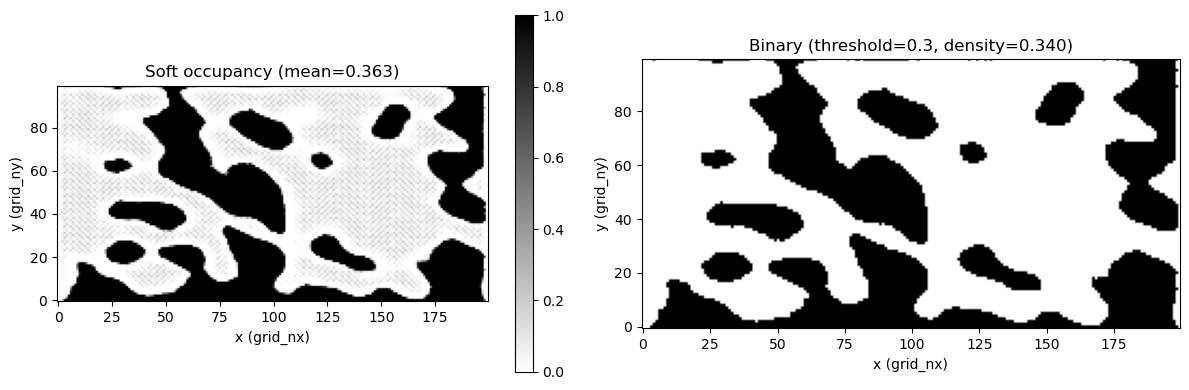

In [35]:
# Run the diagnostic to visualize the CNN output and filter checks after pretraining.
hx_gen.run_diagnostic()

In [36]:
# Save the trained weights
'''trained = False
if trained:
    # Avoid overwriting existing weights if already trained and performance not improved
    hx_gen.save_weights("problems/generator_weights.pth")'''

'trained = False\nif trained:\n    # Avoid overwriting existing weights if already trained and performance not improved\n    hx_gen.save_weights("problems/generator_weights.pth")'

In [37]:
# -------------------------------------------------------------
# Heat Exchanger Simulators
# -------------------------------------------------------------
class Simulator(abc.ABC):
    """
    Abstract base class defining the interface between the Optimizer and
    any simulation backend (MOOSE or PINN in this project).
    
    Sublcasses implement run() and evaluate(). All other Optimizer-
    facing helpers are are provided by the subclasses as appropriate.
    
    Parameters
    ----------
    results_dir : str | Path
        Directory where simulation results are stored (MOOSE Exodus files
        or PINN HDF5 database).
    configs_dir : str | Path
        Directory where GeometryConfig .json files are stored.
    """

    def __init__(
        self,
        results_dir: str | Path,
        configs_dir: str | Path,
    ):
        self.results_dir = Path(results_dir)
        self.configs_dir = Path(configs_dir)
        self.results_dir.mkdir(parents=True, exist_ok=True)

    @abc.abstractmethod
    def run(self, heat_exchanger, **kwargs) -> dict:
        """
        Run a simulation for the given heat exchanger design.
        
        Sets hx.results (dict of field arrays) and hx.solved = True 
        if successful. Returns the results dict.
        
        Parameters
        ----------
        heat_exchanger : HeatExchanger
            The heat exchanger design to simulate. Must have a valid mesh file and GeometryConfig.
        """

    @abc.abstractmethod
    def evaluate(self, heat_exchanger) -> dict:
        """
        Evaluate the simulation results for the given heat exchanger design.
        
        Returns a dict of performance metrics (e.g., pressure drop, heat transfer rate).
        Must be called after run() and only if hx.solved = True.
        
        Parameters
        ----------
        heat_exchanger : HeatExchanger
            The heat exchanger design whose results are to be evaluated.
        """

    @staticmethod
    def _build_grid_centers(gc) -> tuple[np.ndarray, np.ndarray]:
        """
        Build (grid_ny, grid_nx) arrays of cell-centre x and y
        coordinates, consistent with GeometryConfig.cell_center().
        
        x in [0, domain_length], y in [-domain_height/2, +domain_height/2].
        """
        dx = gc.domain_length / gc.grid_nx
        dy = gc.domain_height / gc.grid_ny

        # ix = 0..grid_nx-1, iy = 0..grid_ny-1
        ix = np.arange(gc.grid_nx)
        iy = np.arange(gc.grid_ny)

        x_1d = (ix + 0.5) * dx                          # shape (grid_nx,)
        y_1d = (iy + 0.5) * dy - gc.domain_height / 2   # shape (grid_ny,)

        x_centers = np.tile(x_1d[np.newaxis, :], (gc.grid_ny, 1))
        y_centers = np.tile(y_1d[:, np.newaxis], (1, gc.grid_nx))
        return x_centers, y_centers
    
class MOOSESimulator(Simulator):
    """
    Runs MOOSE CFD Simulations and post-processes Exodus II results.

    Responsibilities
    ----------------
    1. Generate MOOSE .i input files from a Jinja2 template.
    2. Execute MOOSE via subprocess (MPI-parallel)
    3. Read ExodusII (.e) result files with PyVista.
    4. Map unstructured FEM results back to the fixed reference grid.
    5. Extract scalar performance metrics for RL reward.
    6. Build / incrementally update the HDF5 dataset for PINN training.

    Parameters
    ----------
    app_path : str
        Path to the compiled MOOSE application binary.
        Default './cutthroat-opt'.
    template_path : str | Path
        Path to the Jinja2 MOOSE .i template file.
    results_dir : str | Path
        Directory for .e result files and temporary .i input files.
    configs_dir : str | Path
        Directory containing GeometryConfig .json files.
    meshes_dir : str | Path
        Directory containing mesh files (.msh) for each heat exchanger.
    n_processors : int
        Number of MPI processes to use for MOOSE simulations.
    threshold : float
        Binarisation threshold for occupancy grid (default 0.5).
        Used to classify solid vs. fluid cells when mapping results.
    interpolation : str
        'nearest' - KD-tree nearest-neighbor (default, robust)
        'linear'  - scipy griddata linear (smoother near boundaries)
    solid_fill : float
        Value to fill solid cells with in the mapped field arrays (default NaN).
    fluid_properties : dict
        Physical fluid properties substituted into the MOOSE input file
        Keys : 'rho', 'mu', 'k', 'cp'.
    verbose : bool
        Print mesh diagnostics and field names when reading Exodus files.
    """

    # Names of fileds as stored in the Exodus file
    EXODUS_VEL_NAME = "vel_"        # 3-component vector field (u, v, w)
    EXODUS_PRES_NAME = "p"          # scalar pressure field
    EXODUS_TEMP_NAME = "T"          # scalar temperature field

    def __init__(
        self,
        app_path: str = "./cutthroat-opt",
        template_path: str | Path = "problems/template.i",
        results_dir: str | Path = "results",
        configs_dir: str | Path = "configs",
        meshes_dir: str | Path = "meshes",
        n_processors: int = 4,
        threshold: float = 0.3,
        interpolation: str = "nearest",
        solid_fill: float = float("nan"),
        fluid_properties: Optional[dict] = None,
        verbose: bool = True,
    ):
        super().__init__(results_dir=results_dir, configs_dir=configs_dir)
        self.app_path           = app_path
        self.template_path      = Path(template_path)
        self.meshes_dir         = Path(meshes_dir)
        self.n_processors       = n_processors
        self.threshold          = threshold
        self.interpolation      = interpolation
        self.solid_fill         = solid_fill
        self.verbose            = verbose
        self.fluid_properties   = fluid_properties or {
            "rho": 1.0,   # density [kg/m^3]
            "mu": 1.0e-3, # dynamic viscosity [Pa.s]
            "k": 1.0,     # thermal conductivity [W/m.K]
            "cp": 1.0,    # specific heat capacity [J/kg.K]
        }

    def run(self, heat_exchanger, n_processors: Optional[int] = None) -> dict:
        """
        Generate a MOOSE input file, run the simulation, read results,
        map them onto the reference grid, and populate hx.results.
    

        Parameters
        ----------
        heat_exchanger : HeatExchanger
            The heat exchanger design to simulate. Must have a valid mesh file and GeometryConfig.
        n_processors : int | None
            Number of MPI processes to use. If None, uses self.n_processors.

        Returns
        -------
        dict with keys: 'occupancy', 'u', 'v', 'p', 'T'
            Each value is a (grid_ny, grid_nx) float32 ndarray.
            Solid cells hold self.solid_fill (NaN by default).
        """
        hx = heat_exchanger
        n_proc = n_processors or self.n_processors

        # 1. Generate MOOSE input file
        mesh_name = Path(hx.mesh_filename)
        input_file = self.create_input_file(output_dir=self.results_dir, mesh_name=mesh_name)

        # 2. Run MOOSE
        try:
            self._run_moose(input_file=str(input_file), n_processors=n_proc)
        finally:
            # Always clean up the .i file, even on failure
            #self._clean_input_file(input_file)
            pass
        
        # 3. Read and map results
        results = self.read_results(exodus_path=hx.result_filename,
                                    geometry_config=hx.geometry_config
                                    )
        
        # 4. Attach to heat exchanger
        hx.results = results
        hx.solved = True
        return hx, results
    
    def evaluate(self, heat_exchanger) -> float:
        """
        Compute a scalar reward from simulation results.
        
        Current metric: outlet bulk temperature minus inlet bulk temperature,
        normalized by the maximum possible rise (all fluid cells at T_max).
        A higher value means better heat transfer.
        
        Requires hx.results to be populated (hx.solved = True). Call run() first.
        
        Returns
        -------
        float - scalar reward in [0, 1], where 1 is the best possible heat transfer.
        """
        hx = heat_exchanger
        if not hx.solved or hx.results is None:
            # return NaN if the simulation was not run or failed
            return float("nan")

        T = hx.results.get("T")
        occ = hx.results.get("occupancy")
        if T is None or occ is None:
            return float("nan")

        fluid_mask = occ < self.threshold

        inlet_fluid = fluid_mask[:, 0]
        outlet_fluid = fluid_mask[:, -1]

        if inlet_fluid.sum() == 0 or outlet_fluid.sum() == 0:
            logger.warning("No fluid cells at inlet or outlet — cannot compute reward.")
            return float("nan")

        T_in = np.nanmean(T[:, 0][inlet_fluid])
        T_out = np.nanmean(T[:, -1][outlet_fluid])

        # Normalise by overall temperature range so reward is scale-invariant
        T_all_fluid = T[fluid_mask]
        T_range = np.nanmax(T_all_fluid) - np.nanmin(T_all_fluid)
        if T_range < 1e-12:
            return float("nan")

        return float((T_out - T_in) / T_range)

    def create_input_file(self, mesh_name: str, output_dir: Optional[str | Path] = None) -> Path:
        """
        Render the Jinja2 MOOSE .i template for one mesh and write it
        to disk. Returns the path to the written .i file.
        
        The case ID is extracted from the mesh filename stem by stripping
        the .msh extension (e.g. 'hx_20x10-0.050m-t0001.msh' → 'hx_20x10-0.050m-t0001').
        
        Parameters
        ----------
        mesh_name : str
            Name of the mesh file (e.g., 'hx_20x10-0.050m-t0001.msh').
        output_dir : str | Path | None
            Directory to write the .i file. If None, uses self.results_dir.
        """
        output_dir = Path(output_dir) if output_dir else self.results_dir
        output_dir.mkdir(parents=True, exist_ok=True)

        case_id = Path(mesh_name).stem  # e.g., 'hx_20x10-0.050m-t0001'
        input_filename = f"{case_id}.i"

        with open(self.template_path, "r") as f:
            template = Template(f.read())

        rendered = template.render(
            mesh_name=mesh_name,
            case_name=case_id,
            rho=self.fluid_properties["rho"],
            mu=self.fluid_properties["mu"],
            k=self.fluid_properties["k"],
            cp=self.fluid_properties["cp"]
        )

        output_path = output_dir / input_filename
        with open(output_path, "w") as f:
            f.write(rendered)

        return output_path

    def _run_moose(self, input_file: str, n_processors: int) -> None:
        """
        Execute MOOSE via subprocess inside the 'moose' conda environment.
        
        Raises RuntimeError if the MOOSE run fails (non-zero exit code).
        """
        cmd = [
            "conda", "run", "-n", "moose",
            "mpiexec", "-np", str(n_processors),
            self.app_path,
            "-i", input_file,
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                f"MOOSE simulation failed for {input_file} with exit code {result.returncode}.\n"
                f"Error output:\n{result.stderr}"
            )
        if self.verbose:
            print(result.stdout)
    
    def _clean_input_file(self, input_file: str | Path) -> None:
        """
        Delete the temporary MOOSE .i input file after simulation.
        """
        try:
            os.remove(input_file)
        except OSError as e:
            logger.warning(f"Failed to delete input file {input_file}: {e}")

    def load_exodus_mesh(self, exodus_path: str | Path) -> pv.DataSet:
        """
        Read an Exodus II file and return a single merged PyVista dataset
        at the final time step, with cell data promoted to point data.
        
        Parameters
        ----------
        exodus_path : str | Path
            Path to the Exodus II file.
        
        Returns
        -------
        pv.DataSet
            Merged PyVista dataset.
        """
        exodus_path = str(exodus_path)
        reader = pv.get_reader(exodus_path)
        reader.set_active_time_value(reader.time_values[-1])  # last time step
        mb = reader.read()

        # Filter out empty blocks before mergine - avoids PyVista warnings
        valid_blocks = self._extract_valid_blocks(mb)
        if not valid_blocks:
            raise RuntimeError(
                f"No non-empty blocks found in {exodus_path}. "
                "The simulation may have failed or written an empty results file."
            )
        
        mesh = pv.MultiBlock(valid_blocks).combine()
        mesh = mesh.cell_data_to_point_data()

        if self.verbose:
            print(f"\n[MOOSE Simulator] Exodus file: {Path(exodus_path).name}")
            print(f"  Nodes       : {mesh.n_points}")
            print(f"  Array names : {mesh.array_names}")
            print(f"  Point data  : {list(mesh.point_data.keys())}")

        return mesh
    
    def _extract_valid_blocks(self, block) -> list:
        """
        Recursively collect all non-empty leaf datasets from a PyVista MultiBlock tree.
        A block is 'valid' if it has at least one point and one cell.
        """
        datasets = []
        if isinstance(block, pv.MultiBlock):
            for i in range(block.n_blocks):
                datasets.extend(self._extract_valid_blocks(block[i]))
        else:
            if block is None:
                return []
            if block.n_points == 0 or block.n_cells == 0:
                return []
            datasets.append(block)
        return datasets
    
    def debug_blocks(self, exodus_path: str | Path) -> None:
        """
        Print the block structure of an Exodus II file for debugging purposes.
        """
        reader = pv.get_reader(str(exodus_path))
        reader.set_active_time_value(reader.time_values[-1])  # last time step
        mb = reader.read()
        self._print_block_tree(mb, level=0)

    def _print_block_tree(self, block, level: int) -> None:
        indent = "  " * level
        if isinstance(block, pv.MultiBlock):
            print(f"{indent}MultiBlock (n_blocks={block.n_blocks})")
            for i in range(block.n_blocks):
                self._print_block_tree(block[i], level + 1)
        else:
            pts = block.n_points if block is not None else 0
            cells = block.n_cells if block is not None else 0
            print(f"{indent}Block: points={pts}, cells={cells}, array_names={block.array_names if block is not None else []}")
    
    def extract_fields(
            self,
            mesh: pv.DataSet,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Extract raw node coordinates and field arrays from a merged
        PyVista mesh produced by load_exodus_mesh().

        The velocity field is stored in the Exodus file as a 3-component
        vectore named 'vel_' (MOOSE INS convention). Components are split
        into u (x-velocity) and v (y-velocity).

        Returns
        -------
        coords : ndarray, shape (N, 3) - x, y, z node coordinates
        u      : ndarray, shape (N,)   - x-velocity at each node
        v      : ndarray, shape (N,)   - y-velocity at each node
        p      : ndarray, shape (N,)   - pressure at each node
        T      : ndarray, shape (N,)   - temperature at each node
        """
        coords = np.array(mesh.points, dtype=np.float64)  # shape (N, 3)

        vel = np.array(mesh[self.EXODUS_VEL_NAME], dtype=np.float64)  # shape (N, 3)
        u = vel[:, 0]  # x-velocity
        v = vel[:, 1]  # y-velocity

        p = np.array(mesh[self.EXODUS_PRES_NAME], dtype=np.float64)  # shape (N,)
        T = np.array(mesh[self.EXODUS_TEMP_NAME], dtype=np.float64)  # shape (N,)

        return coords, u, v, p, T
    
    def read_results(
            self,
            exodus_path: str | Path,
            geometry_config,
    ) -> dict[str, np.ndarray]:
        """
        Read a MOOSE Exodus II results file and map the fields onto the
        reference grid defined by GeometryConfig.

        Parameters
        ----------
        exodus_path : str | Path
            Path to the Exodus II file.
        geometry_config : GeometryConfig
            GeometryConfig object defining the reference grid.

        Returns
        -------
        dict with keys: 'occupancy', 'u', 'v', 'p', 'T'
            Each value is a (grid_ny, grid_nx) float32 ndarray.
            Solid cells hold self.solid_fill (NaN by default).
        """
        mesh = self.load_exodus_mesh(exodus_path)
        coords, u, v, p, T = self.extract_fields(mesh)

        gc = geometry_config
        occupancy = np.array(gc.occupancy_grid, dtype=np.float32)  # shape (grid_ny, grid_nx)
        binary = (occupancy >= self.threshold).astype(np.float32)  # 1=solid, 0=fluid
        x_cen, y_cen = self._build_grid_centers(gc)  # shape (grid_ny, grid_nx)

        node_xy = coords[:, :2] # drop z for 2D simulation
        node_fields = {"u": u, "v": v, "p": p, "T": T}

        field_grids = self._map_to_grid(
            x_centers=x_cen,
            y_centers=y_cen,
            binary=binary,
            node_coords=node_xy,
            node_fields=node_fields,
        )
        field_grids["occupancy"] = binary
        return field_grids

    def _map_to_grid(
            self,
            x_centers: np.ndarray,
            y_centers: np.ndarray,
            binary: np.ndarray,
            node_coords: np.ndarray,
            node_fields: dict[str, np.ndarray],
    ) -> dict[str, np.ndarray]:
        """
        Map unstructured node data onto the fixed reference grid.

        For each fluid cell: find the nearest FEM node (KD-tree) and
        copy its field values. Solid cells receive self.solid_fill (NaN by default).

        Parameters
        ----------
        x_centers : ndarray, shape (grid_ny, grid_nx)
            x-coordinates of cell centers.
        y_centers : ndarray, shape (grid_ny, grid_nx)
            y-coordinates of cell centers.
        binary : ndarray, shape (grid_ny, grid_nx)
            Binary occupancy grid (1=solid, 0=fluid).
        node_coords : ndarray, shape (N, 2)
            Unstructured node coordinates from the mesh.
        node_fields : dict
            Dictionary of unstructured field arrays at nodes.

        Returns
        -------
        dict with keys matching node_fields and values as (grid_ny, grid_nx) arrays.
        Solid cells are filled with self.solid_fill (NaN by default).
        """

        grid_ny, grid_nx = binary.shape

        grids = {
            name: np.full((grid_ny, grid_nx), self.solid_fill, dtype=np.float32)
            for name in node_fields
        }

        # Identify fluid cells
        fluid_iy, fluid_ix = np.where(binary < self.threshold)
        if fluid_iy.size == 0:
            return grids  # No fluid cells to map
        
        query_pts = np.column_stack([
            x_centers[fluid_iy, fluid_ix],
            y_centers[fluid_iy, fluid_ix]
        ]) # (n_fluid, 2)

        if self.interpolation == "nearest":
            self._map_nearest(grids, query_pts, fluid_iy, fluid_ix, node_coords, node_fields)
        elif self.interpolation == "linear":
            self._map_linear(grids, query_pts, fluid_iy, fluid_ix, node_coords, node_fields)
        else:
            raise ValueError(f"Unknown interpolation method: {self.interpolation}")
        
        return grids
    
    def _map_nearest(self,
                     grids: dict,
                     query_pts: np.ndarray,
                     fluid_iy: np.ndarray,
                     fluid_ix: np.ndarray,
                     node_coords: np.ndarray,
                     node_fields: dict,
                     ) -> None:
        """
        KD-tree nearest-neighbor mapping of unstructured node data to grid cells. Modifies grids in-place.
        """
        tree = cKDTree(node_coords)
        distances, indices = tree.query(query_pts, k=1, workers=-1)

        # Sanity check: warn if any fluid cell is far from the nearest node, which may indicate a mapping issue.
        max_dist = distances.max()
        if max_dist > 0.5:
            print(f"[MOOSE Simulator] Warning: max distance from fluid cell to nearest node is {max_dist:.3f} m. Check mesh resolution.")

        for name, values in node_fields.items():
            grids[name][fluid_iy, fluid_ix] = values[indices].astype(np.float32)
        
    def _map_linear(self,
                    grids: dict,
                    query_pts: np.ndarray,
                    fluid_iy: np.ndarray,
                    fluid_ix: np.ndarray,
                    node_coords: np.ndarray,
                    node_fields: dict,
                    ) -> None:
        """
        Linear interpolation mapping of unstructured node data to grid cells using scipy.griddata. Modifies grids in-place.
        """
        for name, values in node_fields.items():
            interpolated = griddata(
                points=node_coords,
                values=values,
                xi=query_pts,
                method='linear',
                fill_value=self.solid_fill
            )
            nan_mask = np.isnan(interpolated)
            if nan_mask.any():
                # Fallback to nearest for points outside convex hull
                tree = cKDTree(node_coords)
                _, idx = tree.query(query_pts[nan_mask], k=1, workers=-1)
                interpolated[nan_mask] = values[idx]

            grids[name][fluid_iy, fluid_ix] = interpolated.astype(np.float32)

        # -------------------------------------------------------------------
        # Batch Simulation
        # -------------------------------------------------------------------

        def simulate_all(
                self,
                meshes_dir: Optional[str | Path] = None,
                n_processors: Optional[int] = None,
        ) -> dict:
            """
            Simulate every .msh file that does not yeat have a matching .e result
            
            Parameters
            ----------
            meshes_dir : str | Path | None
                Directory containing mesh files. If None, uses self.meshes_dir.
            n_processors : int | None
                Number of MPI processes to use. If None, uses self.n_processors.

            Returns
            -------
            dict with keys:
                'success' : int - number of successful simulations
                'failed'  : int - number of failed simulations
                'errors'  : list[str] - error messages for failed cases
            """
            meshes_dir = Path(meshes_dir) if meshes_dir else self.meshes_dir
            n_proc = n_processors or self.n_processors

            mesh_files = sorted(meshes_dir.glob("*.msh"))
            result_stems = {p.stem for p in self.results_dir.glob("*.e")}
            
            summary = {"simulated:": 0, "skipped": 0, "failed": 0, "errors": []}

            for mesh_file in mesh_files:
                if mesh_file.stem in result_stems:
                    print(f"[skip] {mesh_file.name} - result already exists.")
                    summary["skipped"] += 1
                    continue

                print(f"[run] {mesh_file.name} - simulating...")
                input_file = self.create_input_file(mesh_name=mesh_file.name)
                try:
                    self._run_moose(str(input_file), n_processors=n_proc)
                    summary["simulated:"] += 1
                except RuntimeError as e:
                    summary["failed"] += 1
                    summary["errors"].append(f"Simulation failed for {mesh_file.name}: {e}")
                    print(f"[fail] {mesh_file.name}: {e}")
                finally:
                    self._clean_input_file(input_file)

            print(
                f"\nSimulation Complete: {summary['simulated:']} simulated, {summary['skipped']} skipped, {summary['failed']} failed."
            )
            return summary
        
        # -------------------------------------------------------------
        # HDF5 Dataset Builder
        # -------------------------------------------------------------

        def build_dataset(self,
                          output_path: str | Path = "pinn_dataset.h5",
                          config_ids: Optional[list[str]] = None,
                          overwrite: bool = False
        ) -> dict:
            """
            Assemble all available .e results into a single HDF5 dataset for PINN training.

            Parameters
            ----------
            output_path : str | Path
                Path to the output HDF5 file.
            config_ids : list[str] | None
                Optional list of config IDs to include. If None, includes all.
            overwrite : bool
                If True, overwrite existing HDF5 file.

            Returns
            -------
            dict with keys:
                'total' : int - total number of cases processed
                'added' : int - number of cases added to the dataset
                'skipped' : int - number of cases skipped (already in dataset)
                'failed' : int - number of cases that failed to process
                'errors' : list[str] - error messages for failed cases
            """
            # Import GeometryConfig from the calling notebook namespace
            try:
                from __main__ import GeometryConfig
            except ImportError:
                raise ImportError("GeometryConfig class must be defined in the main namespace.")
            
            output_path = Path(output_path)
            cases = self._discover_cases(GeometryConfig, config_ids)
            summary = {"total": len(cases), "added": 0, "skipped": 0, "failed": 0, "errors": []}

            if not cases:
                print("[build_dataset] No cases found to process.")
                return summary
            
            mode = 'w' if overwrite else 'a'
            with h5py.File(output_path, mode) as hf:
                cases_grp = hf.require_group("cases")
                if "metadata" not in hf or overwrite:
                    self._write_hdf5_metadata(hf, cases)
                
                for config_id, exodus_path, gc in cases:
                    if not overwrite and config_id in cases_grp:
                        summary["skipped"] += 1
                        continue
                    try:
                        field_grids = self.read_results(exodus_path, gc)
                        self._write_hdf5_case(cases_grp, config_id, field_grids)
                        summary["added"] += 1
                        print(f" [ok] {config_id} - added to dataset.")
                    except Exception as e:
                        summary["failed"] += 1
                        summary["errors"].append(f"Failed to process {config_id}: {e}")
                        print(f" [fail] {config_id}: {e}")
            print(f"\nDataset build complete: {summary['added']} added, {summary['skipped']} skipped, {summary['failed']} failed. -> {output_path}")
            return summary
        
        def _discover_cases(self, GeometryConfig, config_ids) -> list:
            """
            Discover all available cases by matching .e files with GeometryConfig JSONs.

            Returns a list of tuples: (config_id, exodus_path, GeometryConfig)
            """
            cases = []
            for exodus_file in self.results_dir.glob("*.e"):
                config_id = exodus_file.stem
                if config_ids and config_id not in config_ids:
                    continue
                json_path = self.configs_dir / f"{config_id}.json"
                if not json_path.exists():
                    print(f"[warn] No GeometryConfig JSON found for {config_id}. Skipping.")
                    continue
                gc = GeometryConfig.from_json(json_path)
                cases.append((config_id, exodus_file, gc))
            return cases
        
        def _write_hdf5_metadata(self, hf: h5py.File, cases: list) -> None:
            gc = cases[0][2]  # Use the first GeometryConfig for metadata
            meta = hf.require_group("metadata")
            dt = h5py.string_dtype()
            if "config_ids" in meta:
                del meta["config_ids"]
            meta.create_dataset("config_ids", data=[c[0] for c in cases], dtype=dt)
            meta.attrs.update({
                "grid_nx": gc.grid_nx,
                "grid_ny": gc.grid_ny,
                "domain_length": gc.domain_length,
                "domain_height": gc.domain_height,
                "threshold": self.threshold,
                "n_cases": len(cases),
            })

        def _write_hdf5_case(self, cases_grp: h5py.Group, config_id: str, field_grids: dict) -> None:
            _DESCRIPTIONS = {
                "occupancy": "Binary occupancy grid (1=solid, 0=fluid)",
                "u": "x-velocity field (m/s)",
                "v": "y-velocity field (m/s)",
                "p": "Pressure field (Pa)",
                "T": "Temperature field (K)",
                }
            
            if config_id in cases_grp:
                del cases_grp[config_id]
            grp = cases_grp.create_group(config_id)
            for name, arr in field_grids.items():
                ds = grp.create_dataset(
                    name, data=arr, dtype=np.float32, compression="gzip", compression_opts=4
                )
                ds.attrs["description"] = _DESCRIPTIONS.get(name, "")

# -------------------------------------------------------------
# PINN Simulator
# -------------------------------------------------------------
class PINNSimulator(Simulator):
    """
    Surrogate simulator that predicts CFD field distributions using a
    trained physics-informed neural network instead of running MOOSE.
 
    Intended to replace MOOSESimulator in the RL training loop once a
    PINN has been trained on MOOSE-generated data, dramatically reducing
    the cost per RL step.
 
    Parameters
    ----------
    model_path : str | Path
        Path to the saved PINN model weights (.pth file).
    results_dir : str | Path
        Directory for any output files (optional for inference).
    configs_dir : str | Path
        Directory containing GeometryConfig JSON files.
    device : str
        PyTorch device for PINN inference ('cpu', 'cuda', 'mps').
 
    Expected model interface (to be implemented)
    ---------------------------------------------
    The PINN model takes a batch of occupancy grids as input and returns
    predicted field grids:
 
        model.forward(occupancy: Tensor[B, 1, grid_ny, grid_nx])
            → dict[str, Tensor[B, 1, grid_ny, grid_nx]]
              keys: 'u', 'v', 'p', 'T'
 
    The returned tensors will be converted to numpy and packaged in the
    same result dict format as MOOSESimulator.read_results().
    """
 
    def __init__(
        self,
        model_path: str | Path,
        results_dir: str | Path = "results",
        configs_dir: str | Path = "configs",
        device: str = "cpu",
    ):
        super().__init__(results_dir=results_dir, configs_dir=configs_dir)
        self.model_path = Path(model_path)
        self.device     = device
        self.model      = None   # loaded lazily on first call to run()
 
    def _load_model(self):
        """Load the PINN model from disk. Called once on first use."""
        raise NotImplementedError(
            "PINNSimulator._load_model() is not yet implemented. "
            "Train a PINN on MOOSESimulator.build_dataset() output first, "
            "then implement this method to load your model architecture and weights."
        )
 
    def run(self, heat_exchanger, **kwargs) -> dict:
        """
        Run PINN inference for one HeatExchanger.
 
        Loads the model on first call, passes the occupancy grid through
        the network, and returns field grids in the same format as
        MOOSESimulator.read_results().
        """
        raise NotImplementedError(
            "PINNSimulator.run() is not yet implemented. "
            "See class docstring for the expected model interface."
        )
 
    def evaluate(self, heat_exchanger) -> float:
        """
        Compute scalar reward from PINN-predicted results.
        Implementation should mirror MOOSESimulator.evaluate().
        """
        raise NotImplementedError(
            "PINNSimulator.evaluate() is not yet implemented."
        )


In [38]:
# -------------------------------------------------------------
# Optimizer class that ties everything together
# -------------------------------------------------------------

class Optimizer:
    def __init__(self, 
                 domain_dimensions=[2.0, 1.0, 100, 50], 
                 generator_type='pretrained_CNN', 
                 simulator_type='MOOSE',
                 config_files_dir="configs", 
                 mesh_files_dir="meshes", 
                 results_dir="results",
                 device="cpu"
                 ):
        self.config_files_dir = config_files_dir
        self.mesh_files_dir = mesh_files_dir
        self.results_dir = results_dir
        self.device = device
        self.generator = self.initialize_generator(generator_type, domain_dimensions)
        self.simulator = self.initialize_simulator(simulator_type)
        self.heat_exchangers = []
        
    def initialize_generator(self, generator_type, domain_dimensions):
        gen = HeatExchangerGenerator(grid_nx=domain_dimensions[2],
            grid_ny=domain_dimensions[3],
            domain_length=domain_dimensions[0],
            domain_height=domain_dimensions[1],
            latent_dim=32,
            threshold=0.5,
            device=device,
            min_density=0.15,
            max_density=0.80,
            mesh_params={
                "mesh_algorithm": 8,
                "mesh_recombine": 1,
                "mesh_element_order": 2
            }
        )
        if generator_type == 'untrained_CNN':
            gen.pretrain_on_filter(n_steps=3000, batch_size=16, lr=1e-3, log_every=100)
        elif generator_type == 'pretrained_CNN':
            weight_file = f"problems/{domain_dimensions[2]}x{domain_dimensions[3]}-generator_weights.pth"
            gen.load_weights(weight_file)
        return gen
    
    def initialize_simulator(self, simulator_type):
        if simulator_type == 'MOOSE':
            sim = MOOSESimulator(
                app_path="./cutthroat-opt",
                template_path="problems/template.i",
                results_dir=self.results_dir,
                configs_dir=self.config_files_dir,
                meshes_dir=self.mesh_files_dir,
                n_processors=4,
                threshold=0.3,
                interpolation="linear",
                solid_fill=float("nan"),
                fluid_properties={
                    "rho": 1.0,   # density [kg/m^3]
                    "mu": 1.0, # dynamic viscosity [Pa.s]
                    "k": 1.0,     # thermal conductivity [W/m.K]
                    "cp": 1.0     # specific heat capacity [J/kg.K]
                },
                verbose=True
            )
        elif simulator_type == 'PINN':
            sim = PINNSimulator(
                model_path="problems/pinn_model.pth",
                results_dir=self.results_dir,
                configs_dir=self.config_files_dir,
                device=self.device
            )
        else:
            raise ValueError(f"Unknown simulator type: {simulator_type}")
        return sim
    
    def create_id(self, nx: int, ny: int, length: float, gen_mode: str, id_num: int) -> str:
        """
        Create a unique ID string for a geometry or mesh.

        Parameters
        ----------
        nx : int
            Number of grid points in the x-direction.
        ny : int
            Number of grid points in the y-direction.
        length : float
            Length of the domain in the x-direction.
        id_num : int
            Numerical identifier to include in the ID.

        Returns
        -------
        str
            Unique ID string.
        """
        if id_num > 999:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}{id_num}"
        elif id_num > 99:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}0{id_num}"
        elif id_num > 9:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}00{id_num}"
        else:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}000{id_num}"

    def run_simulation(self, input_file, n_processors=None):
        '''Run the simulation using the optimizer's simulator
        
        Parameters:
        - input_file: path to the .i file to run
        - n_processors: number of processors to use for parallel execution if using MOOSE simulator (optional)
        '''
        if n_processors is not None:
            self.simulator.run(input_file, n_processors)
        else:
            self.simulator.run(input_file)

    def generate_and_simulate(self, n_samples=10):
        '''Generate heat exchanger designs and simulate them'''
        print(f"Generating and simulating {n_samples} heat exchanger samples...")
        attempts = 0
        max_attempts = 10
        consecutive_failures = 0
        configs = []
        results = []

        # Count the number of meshes that have already been generated to determine starting point for config IDs
        #config_id_counter = len(list(self.mesh_files_dir.glob("*.msh")))
        config_id_counter = 0
        id_start = config_id_counter
        n_generated = 0

        while len(configs) < n_samples:
            attempts += 1
            id_num = id_start + n_generated
            id_str = self.create_id(
                nx=self.generator.grid_nx,
                ny=self.generator.grid_ny,
                length=self.generator.domain_length,
                gen_mode="t",
                id_num=id_num
            )

            config, soft_grid, hx = self.generator.generate(config_id=id_str)
            if config is None:
                consecutive_failures += 1
                if consecutive_failures >= max_attempts:
                    raise RuntimeError(
                        f"GeometryFilter rejected {consecutive_failures} consecutive "
                        f"samples. Only {len(configs)}/{n_samples} valid geometries produced. "
                        f"Consider relaxing filter bounds or retraining the CNN."
                    )
                continue
            else:
                n_generated += 1
            
            hx, results = self.simulator.run(heat_exchanger=hx)

            consecutive_failures = 0
            configs.append(config)
            self.heat_exchangers.append(hx)
        
        print(f"Generated {n_samples} valid geometries in {attempts} attempts "
              f"({attempts - n_samples} filtered out).")

In [39]:
topology_optimizer = Optimizer(
    domain_dimensions=[2.0, 1.0, 100, 50],
    generator_type='pretrained_CNN',
    simulator_type='MOOSE',
    config_files_dir="configs",
    mesh_files_dir="meshes",
    results_dir="results",
    device=device
)

In [40]:
topology_optimizer.generate_and_simulate(n_samples=3)

Generating and simulating 3 heat exchanger samples...


RuntimeError: MOOSE simulation failed for results/hx_100x50-0.020m-t0000.i with exit code 1.
Error output:

[31m
*** ERROR ***
Unable to open file "/home/austingardiner/projects/cutthroat/results/../mesh/meshes/hx_100x50-0.020m-t0000.msh-mesh.cpa.gz". Check to make sure that it exists and that you have read permission.[39m


[31m
*** ERROR ***
Unable to open file "/home/austingardiner/projects/cutthroat/results/../mesh/meshes/hx_100x50-0.020m-t0000.msh-mesh.cpa.gz". Check to make sure that it exists and that you have read permission.[39m

Abort(1) on node 3 (rank 3 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 1) - process 3

[31m
*** ERROR ***
Unable to open file "/home/austingardiner/projects/cutthroat/results/../mesh/meshes/hx_100x50-0.020m-t0000.msh-mesh.cpa.gz". Check to make sure that it exists and that you have read permission.[39m


[31m
*** ERROR ***
Unable to open file "/home/austingardiner/projects/cutthroat/results/../mesh/meshes/hx_100x50-0.020m-t0000.msh